In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import joblib


#EDA

In [4]:
df = pd.read_csv('hairstyle_prediction_dataset_1000.csv')

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 6)


In [6]:
print("\n Dataset Info:")
print(df.info())


 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   face_width      1000 non-null   int64 
 1   jaw_width       1000 non-null   int64 
 2   forehead_width  1000 non-null   int64 
 3   chin_length     1000 non-null   int64 
 4   face_shape      1000 non-null   object
 5   best_hairstyle  1000 non-null   object
dtypes: int64(4), object(2)
memory usage: 47.0+ KB
None


In [7]:
print("\n Descriptive Stats:")
print(df.describe())


 Descriptive Stats:
        face_width    jaw_width  forehead_width  chin_length
count  1000.000000  1000.000000     1000.000000  1000.000000
mean    148.445000   135.545000      143.497000    49.589000
std       6.477108     9.065658        8.449342     5.336155
min     135.000000   120.000000      130.000000    40.000000
25%     143.000000   128.000000      136.000000    45.000000
50%     149.000000   135.000000      145.000000    49.000000
75%     153.000000   142.000000      151.000000    54.000000
max     159.000000   154.000000      159.000000    59.000000


In [8]:
print("\n Target Value Counts:")
print(df['face_shape'].value_counts())


 Target Value Counts:
face_shape
round     209
oval      203
oblong    199
square    199
heart     190
Name: count, dtype: int64


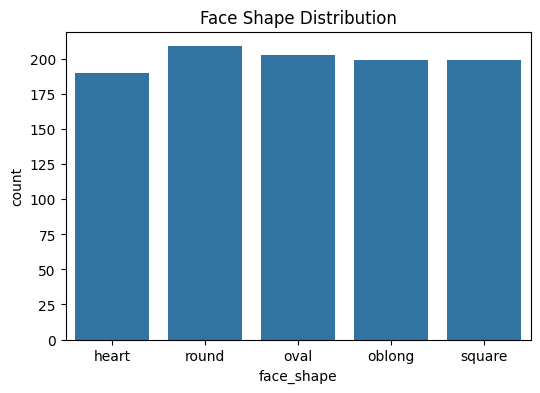

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='face_shape', data=df)
plt.title("Face Shape Distribution")
plt.show()

#Preprocessing

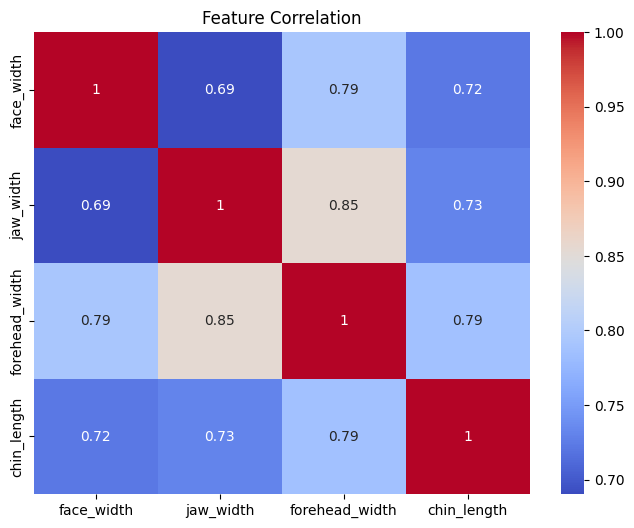

In [10]:
plt.figure(figsize=(8,6))
numeric_features = df.drop(['face_shape', 'best_hairstyle'], axis=1)
sns.heatmap(numeric_features.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [11]:
X = df.drop(['face_shape', 'best_hairstyle'], axis=1)
y = df['face_shape']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Initial Model

In [14]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y_pred = rf_model.predict(X_test)

In [16]:
print("Model Evaluation Results")
print("---------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Model Evaluation Results
---------------------------
Accuracy: 0.935

Classification Report:
               precision    recall  f1-score   support

       heart       0.87      0.81      0.84        32
      oblong       0.95      0.98      0.97        43
        oval       0.97      0.95      0.96        37
       round       0.87      0.91      0.89        43
      square       1.00      1.00      1.00        45

    accuracy                           0.94       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200

Confusion Matrix:
 [[26  0  0  6  0]
 [ 0 42  1  0  0]
 [ 0  2 35  0  0]
 [ 4  0  0 39  0]
 [ 0  0  0  0 45]]


#Hyperparameter Tuning

In [17]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [18]:
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

In [19]:
grid_search.fit(X_train_scaled, y_train)
print("\n Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits

 Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [20]:
best_rf = grid_search.best_estimator_

#final Evalution

In [21]:
y_pred_best = best_rf.predict(X_test_scaled)
print("\n Final Model Evaluation After Tuning")
print("--------------------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))


 Final Model Evaluation After Tuning
--------------------------------------
Accuracy: 0.935

Classification Report:
               precision    recall  f1-score   support

       heart       0.87      0.81      0.84        32
      oblong       0.95      0.98      0.97        43
        oval       0.97      0.95      0.96        37
       round       0.87      0.91      0.89        43
      square       1.00      1.00      1.00        45

    accuracy                           0.94       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200

Confusion Matrix:
 [[26  0  0  6  0]
 [ 0 42  1  0  0]
 [ 0  2 35  0  0]
 [ 4  0  0 39  0]
 [ 0  0  0  0 45]]


#Save model and scaler

In [22]:
folder_path = '../../models/FC110580_nathasha'
os.makedirs(folder_path, exist_ok=True)

In [23]:
model_path = os.path.join(folder_path, 'random_forest_face_shape.pkl')
scaler_path = os.path.join(folder_path, 'scaler.pkl')

In [24]:
joblib.dump(best_rf, model_path)
joblib.dump(scaler, scaler_path)

['../../models/FC110580_nathasha/scaler.pkl']

In [25]:
print(f"\n Model saved successfully as {model_path}")
print(f" Scaler saved successfully as {scaler_path}")


 Model saved successfully as ../../models/FC110580_nathasha/random_forest_face_shape.pkl
 Scaler saved successfully as ../../models/FC110580_nathasha/scaler.pkl
